# Tutorial: generating and using surrogates

This notebook briefly illustrates how to generate and use constrained and typical surrogates for families of continuous distributions, first using synthetic data and then empirical data.

## 0. Contents

**&nbsp;&nbsp;&nbsp;&nbsp;1. Import source code and basic libraries**

**&nbsp;&nbsp;&nbsp;&nbsp;2. Illustration using synthetic data**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.1. Input sequence

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.2. Estimating and applying the lower cut-off

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.3. Constrained and typical surrogates

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.4. Plotting: visually comparing input sequence and surrogates

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.5. Hypothesis testing

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.6. Estimation

**&nbsp;&nbsp;&nbsp;&nbsp;3. Illustration using empirical data**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;3.1. Load bushfire data

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;3.2. Estimating and applying the lower cut-off

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;3.3. Generate surrogates

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;3.4. Plotting: visually comparing input sequence and surrogates

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;3.5. Hypothesis testing

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;3.6. Estimation

## 1. Import source code and basic libraries

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter
import sys
#
sys.path.append("./src/")
from constrained_likelihood_surrogates import *

# Set random seeds so output can be reproduced
np.random.seed(0)
random.seed(0)

## 2. Illustration using synthetic data

### 2.1. Input sequence

Store your input sequence in the variable *seq*.

Here, generate *seq* from one of the five distributions considered in the paper. Change *process* to choose the generating process. We use the parameter values considered in the paper.

For a power-law distribution $p(x)\propto x^{-\gamma}$, $\log(x/x_{\min})$ is exponentially distributed with rate $\alpha=\gamma-1$. We therefore use $\gamma=2.5$ and pass $\alpha=1.5$ to `gen_data`, so that the power-law and exponential parameters correspond directly.

In [2]:
process = 'powerlaw' # Choose from: 'powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform'

x_min = 1
N = 64

gamma = 2.5
param_dict = {
    'powerlaw':[gamma - 1],
    'lognorm':[-1, 1],
    'expon':[1],
    'truncnorm':[-1, 1],
    'uniform':[9],
}

param = param_dict[process]
seq = gen_data(process, N=N, lower_cutoff=x_min, param=param)

print('Generating process: ' + beautify_distribution_name(process))
print('N = ' + str(N))
print(np.round(seq, 3))

Generating process: Powerlaw
N = 64
[ 1.7    2.31   1.851  1.69   1.444  1.998  1.468  4.403  9.115  1.38
  2.846  1.652  1.75   5.653  1.05   1.063  1.014  3.293  2.729  3.897
 12.981  2.916  1.511  2.748  1.088  1.976  1.109  6.887  1.635  1.429
  1.227  2.697  1.501  1.751  1.013  1.898  1.88   1.896  6.811  2.146
  1.346  1.467  2.22   1.042  2.081  2.097  1.171  1.096  1.287  1.352
  1.756  1.469 19.485  1.074  1.169  1.124  2.026  1.215  1.52   1.205
  1.122  1.081  2.038  1.104]


### 2.2. Estimating and applying the lower cut-off

For the synthetic data, the true lower cut-off $x_{\min}=1$ is known. The following shows how a lower cut-off can instead be estimated by minimising the KS distance from the maximum likelihood fit to the selected family.

In [3]:
x_min_KS, _, _, _ = fit_lower_cutoff(seq, model=process)

print('True lower cut-off = ' + str(x_min))
print('KS-distance-minimising lower cut-off = ' + str(x_min_KS))

# For the synthetic-data examples below, instead of the estimated lower cut-off x_min_KS, we will use the known lower cut-off x_min
lower_cutoff = x_min

True lower cut-off = 1
KS-distance-minimising lower cut-off = 1


### 2.3. Constrained and typical surrogates

We consider two surrogate methods for each hypothesised distribution family:

- **Constrained:** generate a surrogate from the hypothesised family while preserving the likelihood of the input sequence, so model parameters do not need to be fitted.
- **Typical:** fit the model parameters by maximum likelihood and generate a new i.i.d. sequence from the fitted distribution.

Bootstrapping, which resamples the input sequence with replacement, can also be used to represent the hypothesis that observations are i.i.d. (without specifying a family of distributions but with the limitation that no new values can be generated).

In [4]:
model_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
method_list = ['constrained', 'typical']

You can generate a surrogate under a chosen distribution family as follows:

In [5]:
model = 'powerlaw'
method = 'constrained'

surr_seq = gen_surrogate_list(seq, model=model, method=method, num_surr=1, lower_cutoff_hat=lower_cutoff)[0]

print('Null model: ' + beautify_distribution_name(model))
print('Surrogate method: ' + beautify_method_name(method))
print(np.round(surr_seq, 3))

Null model: Powerlaw
Surrogate method: Constrained
[ 1.362  1.689  1.397  1.856  7.367  1.021  1.011  1.389  1.919  1.665
  1.813  2.19   2.145  3.082  2.151  1.303  2.593  1.332  2.935  5.887
  4.133  7.351  1.197  2.837  2.27   2.075  1.039  1.323  1.316  4.772
  1.069  1.986  1.175  1.387  1.89   1.037  5.414  1.311  4.647  1.207
  1.485  1.699 10.847  1.045  1.209  1.727  2.258  1.406  4.721  1.398
  5.923  1.126  1.001  1.106  1.15   1.006  1.073  4.776  1.258  1.803
  1.191  4.078  1.215  1.48 ]


Here are one constrained and one typical surrogate under each of the five distribution families, together with a bootstrap surrogate. Only the first few values are printed; the complete sequences are used below.

In [6]:
num_to_print = 8

c_surr_seq_list = []
t_surr_seq_list = []

for model in model_list:#One surrogate per possible hypothesised model ('powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform') 
    c_surr_seq_list.append(gen_surrogate_list(seq, model=model, method='constrained', num_surr=1, lower_cutoff_hat=lower_cutoff)[0])
    t_surr_seq_list.append(gen_surrogate_list(seq, model=model, method='typical', num_surr=1, lower_cutoff_hat=lower_cutoff)[0])

bootstrap_seq = bootstrap(seq)

for i_model, model in enumerate(model_list):
    print(beautify_distribution_name(model) + ' (first ' + str(num_to_print) + ' values):')
    print('  Constrained: ' + str(np.round(c_surr_seq_list[i_model][:num_to_print], 3)))
    print('  Typical:     ' + str(np.round(t_surr_seq_list[i_model][:num_to_print], 3)))
print('Bootstrapped (first ' + str(num_to_print) + ' values): ' + str(np.round(bootstrap_seq[:num_to_print], 3)))

Powerlaw (first 8 values):
  Constrained: [1.199 2.418 4.479 1.172 1.25  1.101 4.274 1.407]
  Typical:     [1.192 1.141 2.489 1.646 2.044 3.048 1.186 1.292]
Lognormal (first 8 values):
  Constrained: [1.164 2.225 1.733 1.167 1.587 3.302 2.033 1.743]
  Typical:     [1.507 1.52  1.575 1.2   5.185 1.224 1.161 1.207]
Exponential (first 8 values):
  Constrained: [1.054 1.18  1.945 1.384 2.217 1.713 3.484 2.15 ]
  Typical:     [1.337 1.778 5.874 1.699 1.541 1.109 1.665 1.404]
Gaussian (first 8 values):
  Constrained: [1.038 1.963 1.698 1.848 1.864 2.025 1.662 1.342]
  Typical:     [1.397 2.274 1.192 1.483 1.495 2.887 1.176 3.165]
Uniform (first 8 values):
  Constrained: [18.107 12.229 18.765 12.473  9.626 13.954 17.812 19.485]
  Typical:     [10.039 13.236 10.807  8.807 13.435 13.395  5.116  8.871]
Bootstrapped (first 8 values): [2.846 1.7   2.729 1.346 1.215 1.652 1.38  2.026]


### 2.4. Plotting: visually comparing input sequence and surrogates

Choose one of the five distribution families to compare the input sequence directly with its constrained, typical, and bootstrapped surrogates:

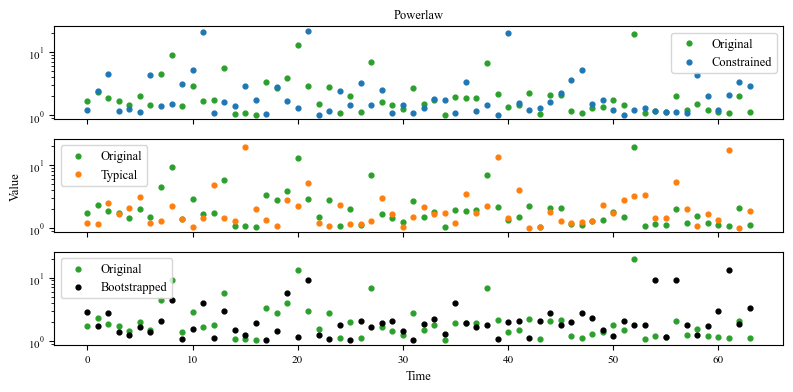

In [7]:
model = process # Choose from model_list
i_model = model_list.index(model)

original_color = 'tab:green'
constrained_color = 'tab:blue'
typical_color = 'tab:orange'
bootstrap_color = 'black'

set_main_fonts(base_font_size=9)
fig, ax_array = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(8, 4))

ax_array[0].scatter(range(N), seq, s=12, label='Original', color=original_color)
ax_array[0].scatter(range(N), c_surr_seq_list[i_model], s=12, label='Constrained', color=constrained_color)
ax_array[0].set_yscale('log')
ax_array[0].legend()
ax_array[0].set_title(beautify_distribution_name(model))

ax_array[1].scatter(range(N), seq, s=12, label='Original', color=original_color)
ax_array[1].scatter(range(N), t_surr_seq_list[i_model], s=12, label='Typical', color=typical_color)
ax_array[1].set_yscale('log')
ax_array[1].set_ylabel('Value')
ax_array[1].legend()

ax_array[2].scatter(range(N), seq, s=12, label='Original', color=original_color)
ax_array[2].scatter(range(N), bootstrap_seq, s=12, label='Bootstrapped', color=bootstrap_color)
ax_array[2].set_yscale('log')
ax_array[2].set_xlabel('Time')
ax_array[2].legend()

fig.tight_layout()
plt.show()

The same input sequence and surrogates can be compared through their empirical complementary cumulative distribution functions. The axes are chosen separately for the different distribution families: logarithmic x- and y-axes for powerlaw and lognormal, a linear x-axis and logarithmic y-axis for exponential and Gaussian, and linear axes for uniform.

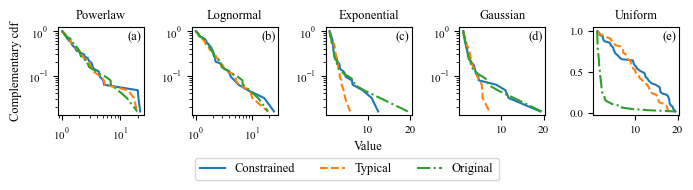

In [8]:
ccdf_x_scale_dict = {
    'powerlaw':'log',
    'lognorm':'log',
    'expon':'linear',
    'truncnorm':'linear',
    'uniform':'linear'
}
ccdf_y_scale_dict = {
    'powerlaw':'log',
    'lognorm':'log',
    'expon':'log',
    'truncnorm':'log',
    'uniform':'linear'
}

x_obs, emp_cdf_obs = ecdf_2(seq, method='min')
emp_ccdf_obs = 1 - np.array(emp_cdf_obs)

set_main_fonts(base_font_size=9)
fig, ax_array = plt.subplots(1, len(model_list), figsize=(7, 2.0))

for i_model, model in enumerate(model_list):
    ax = ax_array[i_model]

    x, emp_cdf = ecdf_2(c_surr_seq_list[i_model], method='min')
    ax.plot(x, 1 - np.array(emp_cdf), label='Constrained', color=constrained_color, linestyle='-')

    x, emp_cdf = ecdf_2(t_surr_seq_list[i_model], method='min')
    ax.plot(x, 1 - np.array(emp_cdf), label='Typical', color=typical_color, linestyle='--')

    ax.plot(x_obs, emp_ccdf_obs, label='Original', color=original_color, linestyle='-.')
    ax.set_xscale(ccdf_x_scale_dict[model])
    ax.set_yscale(ccdf_y_scale_dict[model])
    ax.set_title(beautify_distribution_name(model))

    if (ccdf_x_scale_dict[model] == 'log'):
        ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=10))
        ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10, labelOnlyBase=True))
        ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))
        ax.xaxis.set_minor_formatter(NullFormatter())

    if (ccdf_y_scale_dict[model] == 'log'):
        ax.yaxis.set_minor_formatter(NullFormatter())

ax_array[0].set_ylabel('Complementary cdf')
ax_array[len(model_list)//2].set_xlabel('Value')
handles, labels = ax_array[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.05))
fig.tight_layout(rect=[0, 0.15, 1, 1])
label_subplots(ax_array, corner='upper right', text_kwargs={'font_size':9})
plt.show()

### 2.5. Hypothesis testing

We illustrate hypothesis testing using two statistics:

- **Sample maximum:** We use a lower-directed test to ask whether the hypothesised model tends to produce more extreme events than were observed.
- **KS distance:** We use an upper-directed test to ask whether the goodness of fit is worse than would be expected if the model were correct.

We use 99 surrogates. `calc_surrogate_quantile` applies the same rank calculation and random tie-breaking as the analysis notebooks. For a lower-directed hypothesis test the p-value is the quantile $q$; for an upper-directed hypothesis test it is $1-q$.

In [9]:
num_surr = 99

p_max_mat = np.zeros((len(method_list), len(model_list)))
p_ks_mat = np.zeros((len(method_list), len(model_list)))

for i_model, model in enumerate(model_list):
    obs_max = max_val(seq)
    obs_ks = calc_ks(seq, model=model, lower_cutoff_hat=lower_cutoff)

    for i_method, method in enumerate(method_list):
        surr_seq_list = gen_surrogate_list(seq, model=model, method=method, num_surr=num_surr, lower_cutoff_hat=lower_cutoff)
        surr_max_list = [max_val(surr_seq) for surr_seq in surr_seq_list]
        surr_ks_list = [calc_ks(surr_seq, model=model, lower_cutoff_hat=lower_cutoff) for surr_seq in surr_seq_list]

        p_max_mat[i_method, i_model] = calc_surrogate_quantile(obs_max, surr_max_list)
        p_ks_mat[i_method, i_model] = 1 - calc_surrogate_quantile(obs_ks, surr_ks_list)

print('p-values: lower-directed hypothesis tests using sample maximum:')
print(f"{'Null model':<14}{'Constrained':>14}{'Typical':>14}")
for i_model, model in enumerate(model_list):
    print(f"{beautify_distribution_name(model):<14}{p_max_mat[0, i_model]:>14.3f}{p_max_mat[1, i_model]:>14.3f}")

print()
print('p-values: upper-directed hypothesis tests using KS distance:')
print(f"{'Null model':<14}{'Constrained':>14}{'Typical':>14}")
for i_model, model in enumerate(model_list):
    print(f"{beautify_distribution_name(model):<14}{p_ks_mat[0, i_model]:>14.3f}{p_ks_mat[1, i_model]:>14.3f}")

p-values: lower-directed hypothesis tests using sample maximum:
Null model       Constrained       Typical
Powerlaw               0.515         0.545
Lognormal              0.425         0.545
Exponential            0.975         0.985
Gaussian               0.125         0.995
Uniform                0.175         0.995

p-values: upper-directed hypothesis tests using KS distance:
Null model       Constrained       Typical
Powerlaw               0.495         0.645
Lognormal              0.585         0.665
Exponential            0.075         0.005
Gaussian               0.295         0.005
Uniform                0.005         0.005


For constrained uniform surrogates, the sample maximum is preserved. Its p-value is nevertheless retained: the same random tie-breaking used in the analysis notebooks determines the rank when observed and surrogate statistics are equal.

### 2.6. Estimation

Surrogates can also be used to estimate a statistic under a hypothesised distribution family. Here we estimate the expected sample maximum using 100 surrogates.

For synthetic data, the generating process and its parameters are known, so independent sequences from the true process provide a reference. The boxes below show the distributions of sample maxima and crosses show their means; the horizontal line shows the maximum of the input sequence.

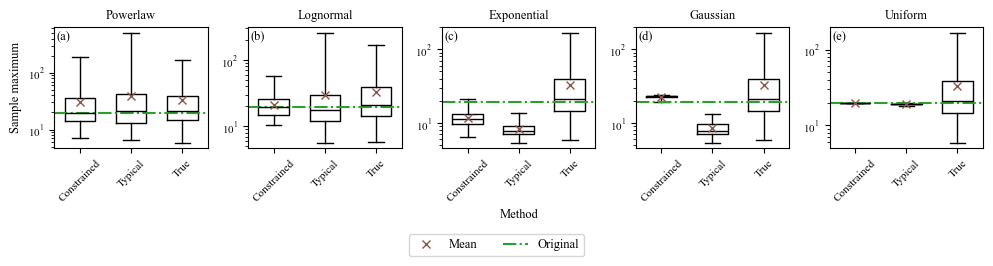

In [10]:
num_surr = 100
mean_color = 'tab:brown'


true_max_list = [max_val(gen_data(process, N=N, lower_cutoff=x_min, param=param)) for i_surr in range(num_surr)]
c_max_list_list = []
t_max_list_list = []

for model in model_list:
    c_surr_seq_list_est = gen_surrogate_list(
        seq, model=model, method='constrained',
        num_surr=num_surr, lower_cutoff_hat=lower_cutoff
    )
    t_surr_seq_list_est = gen_surrogate_list(
        seq, model=model, method='typical',
        num_surr=num_surr, lower_cutoff_hat=lower_cutoff
    )

    c_max_list_list.append([max_val(surr_seq) for surr_seq in c_surr_seq_list_est])
    t_max_list_list.append([max_val(surr_seq) for surr_seq in t_surr_seq_list_est])

set_main_fonts(base_font_size=9)
fig, ax_array = plt.subplots(1, len(model_list), figsize=(10, 2.8))

for i_model, model in enumerate(model_list):
    ax = ax_array[i_model]

    ax.boxplot(
        [c_max_list_list[i_model], t_max_list_list[i_model], true_max_list],
        showmeans=True,
        whis=(0, 100),
        widths=0.6,
        boxprops={'color':'black'},
        whiskerprops={'color':'black'},
        capprops={'color':'black'},
        medianprops={'color':'black'},
        meanprops={'marker':'x', 'markeredgecolor':mean_color, 'markerfacecolor':mean_color, 'markersize':6}
    )

    ax.axhline(max_val(seq), color=original_color, linestyle='-.', linewidth=1.5)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Constrained', 'Typical', 'True'], rotation=45)
    ax.set_yscale('log')
    ax.set_title(beautify_distribution_name(model))

ax_array[0].set_ylabel('Sample maximum')
ax_array[2].set_xlabel('Method')

# Legend entries
mean_handle = plt.Line2D(
    [], [], marker='x', linestyle='None',
    color=mean_color, label='Mean'
)
original_handle = plt.Line2D(
    [], [], color=original_color,
    linestyle='-.', label='Original'
)

fig.legend(handles=[mean_handle, original_handle], loc='lower center', bbox_to_anchor=(0.5, 0.05), ncol=2)

fig.tight_layout(rect=[0, 0.15, 1, 1])
label_subplots(ax_array, corner='upper left', text_kwargs={'font_size':9})
plt.show()

Boxes span the interquartile range and horizontal lines show medians. Whiskers span the full range of the sample maxima. Crosses show means, and the green dot-dashed line shows the maximum of the original sequence. “True” denotes independent sequences generated directly from the process used to generate the input sequence.

## 3. Illustration using empirical data

### 3.1. Load bushfire data

Store the input sequence in the variable *fire_seq*.

Load the sizes of Australian bushfires from July 2019 to June 2020:

In [11]:
year = 2019
fire_seq = np.load('../data/fires/fireSize-' + str(year) + '.npy', 'r')
fire_seq = [int(val) for val in fire_seq]

print('Year = ' + str(year))
print('N = ' + str(len(fire_seq)))
print('Minimum = ' + str(min(fire_seq)) + ', maximum = ' + str(max(fire_seq)))

Year = 2019
N = 8692
Minimum = 1, maximum = 12446


### 3.2. Estimating and applying the lower cut-off

Estimate the lower cut-off separately for each of the five distribution families by minimising the KS distance from the corresponding maximum likelihood fit. The bushfire data are integer-valued, so candidate cut-offs are half-integers immediately below observed values.

In [12]:
lower_cutoff_hat_list = []
fire_seq_list = []

print(f"{'Model':<14}{'x_min':>12}{'N':>8}{'KS distance':>16}")
for model in model_list:
    lower_cutoff_hat, ks, _, _ = fit_lower_cutoff(fire_seq, model=model, continuous=False, ks_method='sup')
    val_seq = [val for val in fire_seq if val >= lower_cutoff_hat]
    lower_cutoff_hat_list.append(lower_cutoff_hat)
    fire_seq_list.append(val_seq)
    print(f"{beautify_distribution_name(model):<14}{lower_cutoff_hat:>12.1f}{len(val_seq):>8d}{ks:>16.3f}")

Model                x_min       N     KS distance
Powerlaw              40.5     417           0.036
Lognormal             32.5     475           0.022
Exponential         1241.5      33           0.151
Gaussian            4806.5      13           0.158
Uniform             2820.5      17           0.174


### 3.3. Generate surrogates

Generate one constrained and one typical surrogate under each of the five distribution families. Each model uses the part of the bushfire dataset above its own estimated lower cut-off. For each of these model-specific input sequences, also generate a bootstrap surrogate.

In [13]:
c_fire_surr_seq_list = []
t_fire_surr_seq_list = []
fire_bootstrap_seq_list = []

for i_model, model in enumerate(model_list):
    val_seq = fire_seq_list[i_model]
    lower_cutoff_hat = lower_cutoff_hat_list[i_model]
    c_fire_surr_seq_list.append(gen_surrogate_list(val_seq, model=model, method='constrained', num_surr=1, lower_cutoff_hat=lower_cutoff_hat)[0])
    t_fire_surr_seq_list.append(gen_surrogate_list(val_seq, model=model, method='typical', num_surr=1, lower_cutoff_hat=lower_cutoff_hat)[0])
    fire_bootstrap_seq_list.append(bootstrap(val_seq))

for i_model, model in enumerate(model_list):
    print(beautify_distribution_name(model) + ' (first ' + str(num_to_print) + ' values):')
    print('  Constrained: ' + str(np.round(c_fire_surr_seq_list[i_model][:num_to_print], 3)))
    print('  Typical:     ' + str(np.round(t_fire_surr_seq_list[i_model][:num_to_print], 3)))
    print('  Bootstrapped: ' + str(np.round(fire_bootstrap_seq_list[i_model][:num_to_print], 3)))

Powerlaw (first 8 values):
  Constrained: [ 65.094  69.56   59.498 147.232 202.822 506.869  48.481 130.273]
  Typical:     [105.375  56.243 962.901 279.32   73.864 416.013 131.442 112.619]
  Bootstrapped: [ 76  44  90 163 109 102 309  78]
Lognormal (first 8 values):
  Constrained: [179.654 642.5   140.774  32.809 237.187 263.287  55.88  459.79 ]
  Typical:     [  375.803  1914.14    212.075    71.83  33808.705   279.222   651.759
    51.122]
  Bootstrapped: [  36   45 1160   88   52 1157 7607  103]
Exponential (first 8 values):
  Constrained: [ 6962.521  1316.582  3917.715  6469.542 12499.04   2421.748  2223.946
  7801.553]
  Typical:     [ 2377.499  2250.114  5790.612  2883.671  3380.263 15191.42   2053.
  4820.592]
  Bootstrapped: [2209 7418 2526 2775 2423 2775 2526 7418]
Gaussian (first 8 values):
  Constrained: [ 9901.58   9449.548 10725.593  6522.416  9245.921 12991.277  6085.402
  7658.248]
  Typical:     [ 9238.049  9129.777 13581.834  8310.13   7545.342  7763.896 10312.199
  74

### 3.4. Plotting: visually comparing input sequence and surrogates

Choose one distribution family to compare the bushfire sequence directly with its constrained, typical, and bootstrapped surrogates:

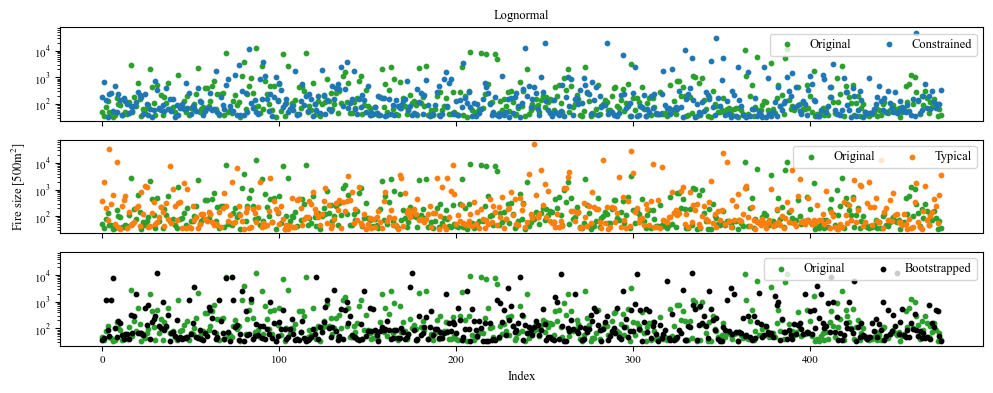

In [14]:
model = 'lognorm' # Choose from model_list
i_model = model_list.index(model)
val_seq = fire_seq_list[i_model]
N_fire = len(val_seq)

set_main_fonts(base_font_size=9)
fig, ax_array = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(10, 4))

ax_array[0].scatter(range(N_fire), val_seq, s=10, label='Original', color=original_color)
ax_array[0].scatter(range(N_fire), c_fire_surr_seq_list[i_model], s=10, label='Constrained', color=constrained_color)
ax_array[0].set_yscale('log')
ax_array[0].legend(ncols=2)
ax_array[0].set_title(beautify_distribution_name(model))

ax_array[1].scatter(range(N_fire), val_seq, s=10, label='Original', color=original_color)
ax_array[1].scatter(range(N_fire), t_fire_surr_seq_list[i_model], s=10, label='Typical', color=typical_color)
ax_array[1].set_yscale('log')
ax_array[1].set_ylabel(r'Fire size [$500\mathrm{m}^2$]')
ax_array[1].legend(ncols=2)

ax_array[2].scatter(range(N_fire), val_seq, s=10, label='Original', color=original_color)
ax_array[2].scatter(range(N_fire), fire_bootstrap_seq_list[i_model], s=10, label='Bootstrapped', color=bootstrap_color)
ax_array[2].set_yscale('log')
ax_array[2].set_xlabel('Index')
ax_array[2].legend(ncols=2)

fig.tight_layout()
plt.show()

Compare the empirical complementary cumulative distribution functions. In each panel, the input sequence contains only observations above the lower cut-off estimated for that model. We use the same axis choices as in Sec. 2.4.

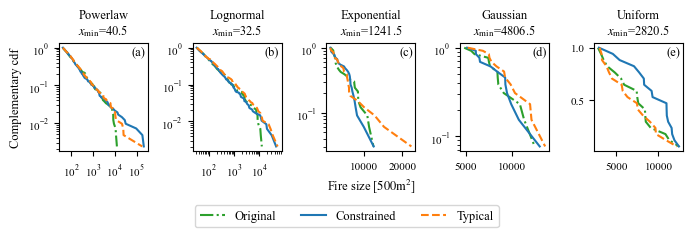

In [15]:
set_main_fonts(base_font_size=9)
fig, ax_array = plt.subplots(1, len(model_list), figsize=(7, 2.5))

for i_model, model in enumerate(model_list):
    ax = ax_array[i_model]

    x, emp_cdf = ecdf_2(fire_seq_list[i_model], method='min')
    ax.plot(x, 1 - np.array(emp_cdf), label='Original', color=original_color, linestyle='-.')

    x, emp_cdf = ecdf_2(c_fire_surr_seq_list[i_model], method='min')
    ax.plot(x, 1 - np.array(emp_cdf), label='Constrained', color=constrained_color, linestyle='-')

    x, emp_cdf = ecdf_2(t_fire_surr_seq_list[i_model], method='min')
    ax.plot(x, 1 - np.array(emp_cdf), label='Typical', color=typical_color, linestyle='--')

    ax.set_xscale(ccdf_x_scale_dict[model])
    ax.set_yscale(ccdf_y_scale_dict[model])
    ax.set_title(beautify_distribution_name(model) + '\n$x_{\\min}$=' + str(lower_cutoff_hat_list[i_model]))

    if (ccdf_x_scale_dict[model] == 'log'):
        ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=10))
        ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10, labelOnlyBase=True))
        ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))
        ax.xaxis.set_minor_formatter(NullFormatter())

    if (ccdf_y_scale_dict[model] == 'log'):
        ax.yaxis.set_minor_formatter(NullFormatter())

ax_array[0].set_ylabel('Complementary cdf')
ax_array[len(model_list)//2].set_xlabel(r'Fire size [$500\mathrm{m}^2$]')
handles, labels = ax_array[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.05))
fig.tight_layout(rect=[0, 0.15, 1, 1])
label_subplots(ax_array, corner='upper right', text_kwargs={'font_size':9})
plt.show()

### 3.5. Hypothesis testing

Repeat the same two hypothesis tests for the bushfire data: a lower-directed hypothesis test using the sample maximum and an upper-directed hypothesis test using the KS distance.

In [16]:
num_surr = 99

fire_p_max_mat = np.zeros((len(method_list), len(model_list)))
fire_p_ks_mat = np.zeros((len(method_list), len(model_list)))

for i_model, model in enumerate(model_list):
    val_seq = fire_seq_list[i_model]
    lower_cutoff_hat = lower_cutoff_hat_list[i_model]
    obs_max = max_val(val_seq)
    obs_ks = calc_ks(val_seq, model=model, lower_cutoff_hat=lower_cutoff_hat)

    for i_method, method in enumerate(method_list):
        surr_seq_list = gen_surrogate_list(val_seq, model=model, method=method, num_surr=num_surr, lower_cutoff_hat=lower_cutoff_hat)
        surr_max_list = [max_val(surr_seq) for surr_seq in surr_seq_list]
        surr_ks_list = [calc_ks(surr_seq, model=model, lower_cutoff_hat=lower_cutoff_hat) for surr_seq in surr_seq_list]

        fire_p_max_mat[i_method, i_model] = calc_surrogate_quantile(obs_max, surr_max_list)
        fire_p_ks_mat[i_method, i_model] = 1 - calc_surrogate_quantile(obs_ks, surr_ks_list)

print('p-values: lower-directed hypothesis tests using sample maximum:')
print(f"{'Null model':<14}{'Constrained':>14}{'Typical':>14}")
for i_model, model in enumerate(model_list):
    print(f"{beautify_distribution_name(model):<14}{fire_p_max_mat[0, i_model]:>14.3f}{fire_p_max_mat[1, i_model]:>14.3f}")

print()
print('p-values: upper-directed hypothesis tests uaing KS distance:')
print(f"{'Null model':<14}{'Constrained':>14}{'Typical':>14}")
for i_model, model in enumerate(model_list):
    print(f"{beautify_distribution_name(model):<14}{fire_p_ks_mat[0, i_model]:>14.3f}{fire_p_ks_mat[1, i_model]:>14.3f}")

p-values: lower-directed hypothesis tests using sample maximum:
Null model       Constrained       Typical
Powerlaw               0.005         0.005
Lognormal              0.015         0.005
Exponential            0.185         0.295
Gaussian               0.355         0.615
Uniform                0.535         0.995

p-values: upper-directed hypothesis tests uaing KS distance:
Null model       Constrained       Typical
Powerlaw               0.365         0.385
Lognormal              0.855         0.825
Exponential            0.025         0.215
Gaussian               0.385         0.535
Uniform                0.615         0.585


### 3.6. Estimation

Estimate the expected sample maximum under each of the five distribution families using 10 surrogates. The boxes below show the distributions of sample maxima and crosses show their means; the horizontal line shows the maximum of the bushfire data above the corresponding lower cut-off.

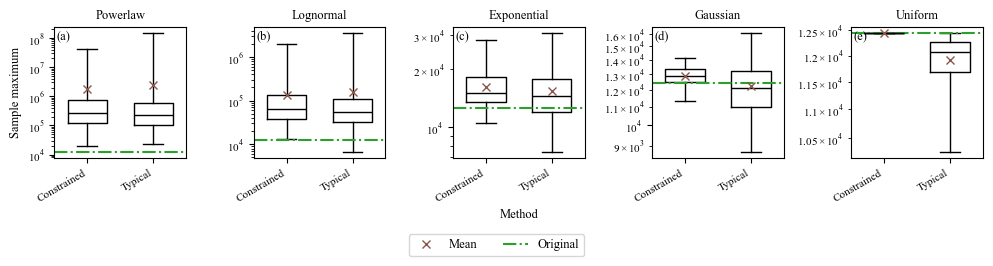

In [17]:
num_surr = 100

c_fire_max_list_list = []
t_fire_max_list_list = []

for i_model, model in enumerate(model_list):
    val_seq = fire_seq_list[i_model]
    lower_cutoff_hat = lower_cutoff_hat_list[i_model]

    c_surr_seq_list_est = gen_surrogate_list(
        val_seq, model=model, method='constrained',
        num_surr=num_surr, lower_cutoff_hat=lower_cutoff_hat
    )
    t_surr_seq_list_est = gen_surrogate_list(
        val_seq, model=model, method='typical',
        num_surr=num_surr, lower_cutoff_hat=lower_cutoff_hat
    )

    c_fire_max_list_list.append([max_val(surr_seq) for surr_seq in c_surr_seq_list_est])
    t_fire_max_list_list.append([max_val(surr_seq) for surr_seq in t_surr_seq_list_est])

set_main_fonts(base_font_size=9)
fig, ax_array = plt.subplots(1, len(model_list), figsize=(10, 2.8))

for i_model, model in enumerate(model_list):
    ax = ax_array[i_model]

    ax.boxplot(
        [c_fire_max_list_list[i_model], t_fire_max_list_list[i_model]],
        showmeans=True,
        whis=(0, 100),
        widths=0.6,
        boxprops={'color':'black'},
        whiskerprops={'color':'black'},
        capprops={'color':'black'},
        medianprops={'color':'black'},
        meanprops={
            'marker':'x',
            'markeredgecolor':mean_color,
            'markerfacecolor':mean_color,
            'markersize':6
        }
    )

    ax.axhline(
        max_val(fire_seq_list[i_model]),
        color=original_color,
        linestyle='-.',
        linewidth=1.5
    )

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Constrained', 'Typical'], rotation=30, ha='right')
    ax.set_yscale('log')
    ax.set_title(beautify_distribution_name(model))

ax_array[0].set_ylabel('Sample maximum')
ax_array[2].set_xlabel('Method')

mean_handle = plt.Line2D(
    [], [], marker='x', linestyle='None',
    color=mean_color, label='Mean'
)
original_handle = plt.Line2D(
    [], [], color=original_color,
    linestyle='-.', label='Original'
)

fig.legend(
    handles=[mean_handle, original_handle],
    loc='lower center',
    bbox_to_anchor=(0.5, 0.05),
    ncol=2,
    
)

fig.tight_layout(rect=[0, 0.15, 1, 1])
label_subplots(ax_array, corner='upper left', text_kwargs={'font_size':9})
plt.show()

Boxes span the interquartile range and horizontal lines show medians. Whiskers span the full range of the sample maxima. Crosses show means, and the green dot-dashed lines show the maxima of the original sequences.